Щоб перейти на GPU (Colab)
Runtime → Change runtime type

У вікні, що відкриється -> Hardware accelerator -> GPU(за замовчуванням там стоїть None → означає CPU)

Save

Colab Free

Час сесії: зазвичай до 12 годин (після цього сесія відключається, навіть якщо ще є ресурс).

Ліміти використання: приблизно 20–30 годин GPU на тиждень

In [1]:
!pip install ucimlrepo

In [2]:
from ucimlrepo import fetch_ucirepo

from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report

import torch
from torch import nn, optim
from torch.utils.data import TensorDataset, DataLoader, random_split

from torchvision import datasets, transforms
from torchvision import models
from torchvision import models

import os
import numpy as np
import matplotlib.pyplot as plt
import random
import pandas as pd
import time
from collections import Counter


import kagglehub

import re
import string
import nltk
from nltk.tokenize import word_tokenize
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [25]:
torch.manual_seed(42)
random.seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


# Task 1

1. Повнозв'язані нейронні мережі.
Візьміть дані, з якими ви працювали в лабораторній №1.  Побудуйте повнозв’язану нейронну мережу
прямого поширення () для задачі класифікації.
Навчіть її на тренувальній вибірці, протестуйте на тестовій. Порівняйте результати з алгоритмами з Lab 1.

## Data

In [ ]:
# fetch dataset
drug_consumption_quantified = fetch_ucirepo(id=373)

# data (as pandas dataframes)
X = drug_consumption_quantified.data.features
y = drug_consumption_quantified.data.targets

# metadata
# print(drug_consumption_quantified.metadata)

# variable information
# print(drug_consumption_quantified.variables)


In [ ]:
dataset_with_targets = drug_consumption_quantified.data.original

In [ ]:
cols_to_drop = [col for col in y.columns if col != 'cannabis']

# Видаляємо їх із dataset_with_targets
new_dataset_with_targets = dataset_with_targets.drop(columns=cols_to_drop)
new_dataset_with_targets = new_dataset_with_targets.drop(columns='id')
new_dataset_with_targets['cannabis'] = new_dataset_with_targets['cannabis'].replace(
    {f'CL{i}': i for i in range(7)}
).astype(int)
# Перевіримо результат
new_dataset_with_targets.head()

/tmp/ipython-input-1077137910.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  new_dataset_with_targets['cannabis'] = new_dataset_with_targets['cannabis'].replace(


,age,gender,education,country,ethnicity,nscore,escore,oscore,ascore,cscore,impuslive,ss,cannabis
0,0.49788,0.48246,-0.05921,0.96082,0.12600,0.31287,-0.57545,-0.58331,-0.91699,-0.00665,-0.21712,-1.18084,0
1,-0.07854,-0.48246,1.98437,0.96082,-0.31685,-0.67825,1.93886,1.43533,0.76096,-0.14277,-0.71126,-0.21575,4
2,0.49788,-0.48246,-0.05921,0.96082,-0.31685,-0.46725,0.80523,-0.84732,-1.62090,-1.01450,-1.37983,0.40148,3
3,-0.95197,0.48246,1.16365,0.96082,-0.31685,-0.14882,-0.80615,-0.01928,0.59042,0.58489,-1.37983,-1.18084,2
4,0.49788,0.48246,1.98437,0.96082,-0.31685,0.73545,-1.63340,-0.45174,-0.30172,1.30612,-0.21712,-0.21575,3


In [ ]:
new_dataset_with_targets.shape

(1885, 13)

In [ ]:
mapping3 = {
    0: 0, 1: 0, 2: 0,
    3: 1, 4: 1, 5: 1, 6: 1
}
new_dataset_with_targets['cannabis_new3'] = new_dataset_with_targets['cannabis'].map(mapping3)

In [ ]:
targets = ['cannabis', 'cannabis_new3']

In [ ]:
new_dataset_with_targets['cannabis'].dtype

dtype('int64')

## Model

In [ ]:
X = new_dataset_with_targets.drop(targets, axis=1)
y = new_dataset_with_targets['cannabis'].values  # перетворюємо в array

# === Масштабування ===
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# train-test split зі збереженням пропорцій класів
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.20, random_state=42, stratify=y)

In [ ]:
# === Конвертація в тензори ===
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)  # torch.long — це еквівалент типу int64, але саме цей тип очікує функція втрат nn.CrossEntropyLoss
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.long)

Без DataLoader: Всі дані подаються в модель одразу → може бути повільно і споживати багато пам’яті.	Неможливо перемішати приклади на кожній епосі.Тренування менш стабільне.

З DataLoader: Дані діляться на batch-и, що дозволяє тренувати навіть дуже великі набори.shuffle=True перемішує дані кожного разу → краще узагальнення. Плавне навчання за допомогою міні-батчів.

In [ ]:
# Створюємо TensorDataset
train_data = TensorDataset(X_train, y_train)
test_data  = TensorDataset(X_test, y_test)

# Створюємо DataLoader-и
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_data,  batch_size=32, shuffle=False)

In [ ]:
for xb, yb in train_loader:
    print(xb.shape, yb.shape)
    break

torch.Size([32, 12]) torch.Size([32])


Як підбирати кількість нейронів

Є кілька емпіричних правил:

Почати з числа нейронів ≈ 2–8× кількість ознак ( 12 → 24–96 — ідеально).

Зменшувати кількість на кожному наступному шарі (64 → 32 → 16 → ...).

Підбирати за validation accuracy / loss — експериментально.

Вихідний шар без активації, бо CrossEntropyLoss вже містить LogSoftmax

In [ ]:
class MLP(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 64), nn.ReLU(),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, output_dim)
        )

    def forward(self, x):
        logits = self.network(x)
        return logits

In [ ]:
# Ініціалізація
input_dim = X_train.shape[1]  # 12 ознак
output_dim = len(set(y))  # кількість класів
print(input_dim, output_dim)


model = MLP(12, 7).to(device)
print(model)

12 7
MLP(
  (network): Sequential(
    (0): Linear(in_features=12, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=7, bias=True)
  )
)


In [ ]:
for name, param in model.named_parameters():
    if param.requires_grad:
        print(name, param.numel())

network.0.weight 768
network.0.bias 64
network.2.weight 2048
network.2.bias 32
network.4.weight 224
network.4.bias 7


In [ ]:
# Loss & Optimizer
criterion = nn.CrossEntropyLoss() # для класифікації
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)  # lr=1e-3

model.train() → вмикає "режим навчання" (активує dropout, batchnorm тощо, якщо є).

optimizer.zero_grad() → обнуляє старі градієнти, щоб не накопичувались.

loss.backward() → запускає зворотне поширення помилки.

optimizer.step() → оновлює параметри моделі (використовуючи обчислені градієнти).

train_loss — середній loss за всю епоху.

---

model.eval() → переводить модель у режим оцінювання (вимикає dropout, batchnorm тощо).

torch.no_grad() → не обчислює градієнти (щоб прискорити і зменшити пам’ять).

Ми просто обчислюємо loss, не оновлюючи ваги.

val_loss показує, наскільки добре модель узагальнює на нових даних.

In [ ]:
# Навчання

n_epochs = 20

train_loss_history = []
val_loss_history = []
for epoch in range(n_epochs):

    # --- train ---
    model.train()
    train_loss = 0.0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    # --- validation ---
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss = criterion(out, y)
            val_loss += loss.item()
    val_loss /= len(test_loader)

    train_loss_history.append(train_loss)
    val_loss_history.append(val_loss)
    print(f"[{epoch+1:02d}] train_loss={train_loss:.4f} | val_loss={val_loss:.4f}")

[01] train_loss=1.6361 | val_loss=1.5605
[02] train_loss=1.5081 | val_loss=1.5201
[03] train_loss=1.4920 | val_loss=1.5322
[04] train_loss=1.4620 | val_loss=1.5610
[05] train_loss=1.4413 | val_loss=1.5487
[06] train_loss=1.4503 | val_loss=1.5356
[07] train_loss=1.4189 | val_loss=1.5428
[08] train_loss=1.4076 | val_loss=1.5634
[09] train_loss=1.4188 | val_loss=1.5674
[10] train_loss=1.3981 | val_loss=1.5925
[11] train_loss=1.3631 | val_loss=1.5918
[12] train_loss=1.3280 | val_loss=1.6690
[13] train_loss=1.3117 | val_loss=1.6167
[14] train_loss=1.2973 | val_loss=1.6839
[15] train_loss=1.2605 | val_loss=1.7277
[16] train_loss=1.2397 | val_loss=1.7550
[17] train_loss=1.2472 | val_loss=1.8204
[18] train_loss=1.2489 | val_loss=1.7824
[19] train_loss=1.2648 | val_loss=1.8331
[20] train_loss=1.2039 | val_loss=1.8565


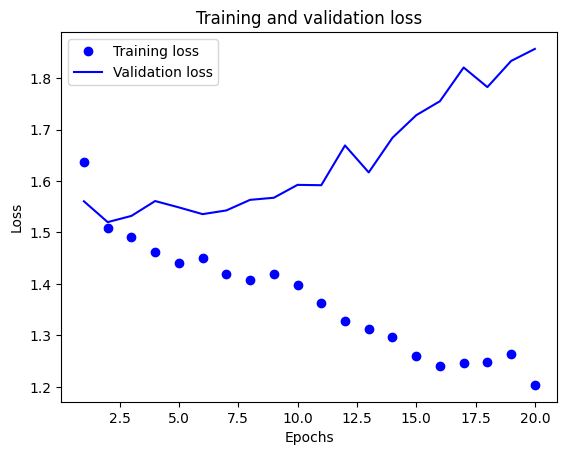

In [ ]:
epochs = range(1, len(train_loss_history) + 1)
plt.plot(epochs, train_loss_history, "bo", label="Training loss")
plt.plot(epochs, val_loss_history, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:
model.eval()
y_true, y_pred = [], []

correct, total = 0, 0  # 🔹 ініціалізація

with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        out = model(x)
        preds = torch.argmax(out, dim=1)
        y_true.extend(y.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())
        correct += (preds == y).sum().item()
        total += y.size(0)

print(f"Final Test Accuracy: {correct/total*100:.2f}%")
print(classification_report(y_true, y_pred, digits=3))

Final Test Accuracy: 38.46%
              precision    recall  f1-score   support

           0      0.536     0.542     0.539        83
           1      0.324     0.268     0.293        41
           2      0.259     0.264     0.262        53
           3      0.190     0.095     0.127        42
           4      0.062     0.036     0.045        28
           5      0.125     0.027     0.044        37
           6      0.431     0.742     0.545        93

    accuracy                          0.385       377
   macro avg      0.275     0.282     0.265       377
weighted avg      0.334     0.385     0.344       377



train_loss ↓, а val_loss ↑, — це overfitting (модель запам’ятовує тренувальні приклади, але не узагальнює).

Спробуємо змінити параметри моделі, а саме, додати:

Dropout (0.3 і 0.2) — зменшує перенавчання.

weight_decay=1e-4 — L2-регуляризація.

clip_grad_norm_ — запобігає "вибуху" градієнтів.

збереження найкращої моделі за val_loss.

In [ ]:
# --- модель ---
class MLP(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),           # Dropout після першого шару
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),           # Ще Dropout
            nn.Linear(32, output_dim)
        )

    def forward(self, x):
        logits = self.network(x)
        return logits


# --- створюємо модель ---
model = MLP(12, 7).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)  # L2 регуляризація

n_epochs = 50
best_val_loss = float("inf")
train_loss_history = []
val_loss_history = []

for epoch in range(n_epochs):
    # --- TRAIN ---
    model.train()
    train_loss = 0.0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()

        # 🔹 обмежуємо градієнти, щоб уникнути вибуху градієнтів
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)

        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    # --- VALIDATION ---
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss = criterion(out, y)
            val_loss += loss.item()
    val_loss /= len(test_loader)

    train_loss_history.append(train_loss)
    val_loss_history.append(val_loss)

    # 🔹 Збереження найкращої моделі (мінімальний val_loss)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model.state_dict()

    print(f"[{epoch+1:02d}] train_loss={train_loss:.4f} | val_loss={val_loss:.4f}")

# --- Після тренування: завантажуємо найкращу модель ---
model.load_state_dict(best_model_state)
print("\n✅ Навчання завершено. Найкраща модель збережена з val_loss =", round(best_val_loss, 4))


[01] train_loss=1.8846 | val_loss=1.7914
[02] train_loss=1.7258 | val_loss=1.6460
[03] train_loss=1.6253 | val_loss=1.5784
[04] train_loss=1.5809 | val_loss=1.5527
[05] train_loss=1.5600 | val_loss=1.5403
[06] train_loss=1.5305 | val_loss=1.5387
[07] train_loss=1.5339 | val_loss=1.5339
[08] train_loss=1.5338 | val_loss=1.5326
[09] train_loss=1.5232 | val_loss=1.5297
[10] train_loss=1.5293 | val_loss=1.5241
[11] train_loss=1.5035 | val_loss=1.5211
[12] train_loss=1.4958 | val_loss=1.5215
[13] train_loss=1.4957 | val_loss=1.5249
[14] train_loss=1.5044 | val_loss=1.5236
[15] train_loss=1.4992 | val_loss=1.5214
[16] train_loss=1.5045 | val_loss=1.5252
[17] train_loss=1.4985 | val_loss=1.5218
[18] train_loss=1.4927 | val_loss=1.5262
[19] train_loss=1.4807 | val_loss=1.5202
[20] train_loss=1.4720 | val_loss=1.5219
[21] train_loss=1.4732 | val_loss=1.5225
[22] train_loss=1.4728 | val_loss=1.5216
[23] train_loss=1.4731 | val_loss=1.5183
[24] train_loss=1.4783 | val_loss=1.5206
[25] train_loss=

In [ ]:
print(input_dim, output_dim)

12 7


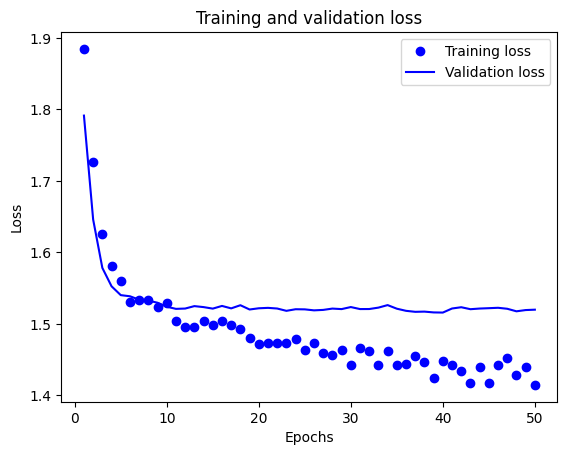

In [ ]:
epochs = range(1, len(train_loss_history) + 1)
plt.plot(epochs, train_loss_history, "bo", label="Training loss")
plt.plot(epochs, val_loss_history, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:
model.eval()
y_true, y_pred = [], []

correct, total = 0, 0  # 🔹 ініціалізація

with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        out = model(x)
        preds = torch.argmax(out, dim=1)
        y_true.extend(y.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())
        correct += (preds == y).sum().item()
        total += y.size(0)

print(f"Final Test Accuracy: {correct/total*100:.2f}%")
print(classification_report(y_true, y_pred, digits=3))

Final Test Accuracy: 43.77%
              precision    recall  f1-score   support

           0      0.485     0.771     0.595        83
           1      0.367     0.268     0.310        41
           2      0.188     0.057     0.087        53
           3      0.154     0.048     0.073        42
           4      0.000     0.000     0.000        28
           5      0.286     0.054     0.091        37
           6      0.464     0.892     0.610        93

    accuracy                          0.438       377
   macro avg      0.277     0.299     0.252       377
weighted avg      0.333     0.438     0.345       377



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Нейромережа вчиться, але не досягає сильної узагальнювальної здатності. Значення loss ≈ 1.5 для CrossEntropyLoss означає, що передбачення далекі від правильних класів — імовірності ще близькі до випадкових. Класи незбалансовані, а також, можливо, модель замала для 12 ознак.

In [ ]:
pd.Series(y_train.numpy()).value_counts(normalize=True)

,proportion
6,0.245358
0,0.218833
2,0.141247
3,0.112069
1,0.110080
5,0.098143
4,0.074271


Класи дійсно не збалансовані, що було відомо ще в першій лабораторній роботі.

---
Спробуємо збільшити модель, можливо це покращить результат. Додамо шар та застосуємо nn.ReLU() → nn.LeakyReLU(0.1), (0.1 означає, що для від’ємних значень градієнт не обнуляється повністю, а залишається 0.1 * x).
Це допомагає уникнути "мертвих нейронів", коли ReLU просто "вимикає" частину шару.


In [ ]:
# --- модель ---
class MLP(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.2),

            nn.Linear(64, 32),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.1),

            nn.Linear(32, output_dim)
        )

    def forward(self, x):
        return self.network(x)


# --- створюємо модель ---
model = MLP(12, 7).to(device)

# --- Балансування класів ---
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(y_train.numpy()),
    y=y_train.numpy()
)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

# criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)  # L2 регуляризація

n_epochs = 50
best_val_loss = float("inf")
train_loss_history = []
val_loss_history = []

for epoch in range(n_epochs):
    # --- TRAIN ---
    model.train()
    train_loss = 0.0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()

        # 🔹 обмежуємо градієнти, щоб уникнути вибуху градієнтів
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)

        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    # --- VALIDATION ---
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss = criterion(out, y)
            val_loss += loss.item()
    val_loss /= len(test_loader)

    train_loss_history.append(train_loss)
    val_loss_history.append(val_loss)

    # 🔹 Збереження найкращої моделі (мінімальний val_loss)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model.state_dict()

    print(f"[{epoch+1:02d}] train_loss={train_loss:.4f} | val_loss={val_loss:.4f}")

# --- Після тренування: завантажуємо найкращу модель ---
model.load_state_dict(best_model_state)
print("\n✅ Навчання завершено. Найкраща модель збережена з val_loss =", round(best_val_loss, 4))


[01] train_loss=1.8935 | val_loss=1.7969
[02] train_loss=1.7072 | val_loss=1.6894
[03] train_loss=1.6528 | val_loss=1.6805
[04] train_loss=1.6342 | val_loss=1.6782
[05] train_loss=1.6159 | val_loss=1.6785
[06] train_loss=1.6167 | val_loss=1.6702
[07] train_loss=1.6129 | val_loss=1.6743
[08] train_loss=1.5962 | val_loss=1.6675
[09] train_loss=1.6311 | val_loss=1.6645
[10] train_loss=1.5816 | val_loss=1.6575
[11] train_loss=1.5748 | val_loss=1.6629
[12] train_loss=1.5679 | val_loss=1.6759
[13] train_loss=1.5632 | val_loss=1.6685
[14] train_loss=1.5740 | val_loss=1.6594
[15] train_loss=1.5623 | val_loss=1.6705
[16] train_loss=1.5542 | val_loss=1.6664
[17] train_loss=1.5382 | val_loss=1.6669
[18] train_loss=1.5597 | val_loss=1.6708
[19] train_loss=1.5493 | val_loss=1.6758
[20] train_loss=1.5393 | val_loss=1.6747
[21] train_loss=1.5193 | val_loss=1.6755
[22] train_loss=1.5467 | val_loss=1.6764
[23] train_loss=1.5163 | val_loss=1.6686
[24] train_loss=1.5201 | val_loss=1.6694
[25] train_loss=

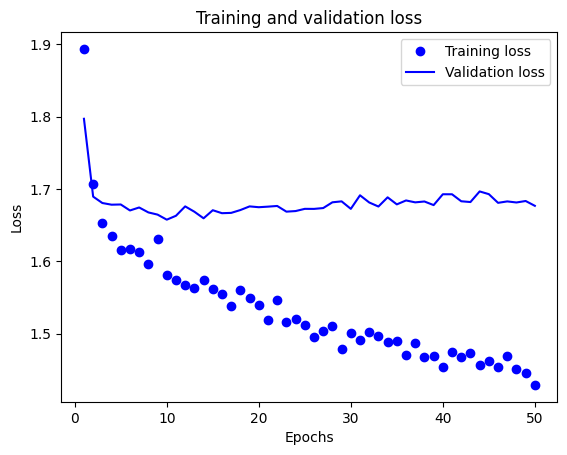

In [ ]:
epochs = range(1, len(train_loss_history) + 1)
plt.plot(epochs, train_loss_history, "bo", label="Training loss")
plt.plot(epochs, val_loss_history, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:
model.eval()
y_true, y_pred = [], []


correct, total = 0, 0  # 🔹 ініціалізація
with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        out = model(x)
        preds = torch.argmax(out, dim=1)
        y_true.extend(y.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())
        correct += (preds == y).sum().item()
        total += y.size(0)

print(f"Final Test Accuracy: {correct/total*100:.2f}%")
print(classification_report(y_true, y_pred, digits=3))

Final Test Accuracy: 31.03%
              precision    recall  f1-score   support

           0      0.547     0.422     0.476        83
           1      0.292     0.512     0.372        41
           2      0.341     0.264     0.298        53
           3      0.114     0.119     0.116        42
           4      0.115     0.250     0.157        28
           5      0.184     0.189     0.187        37
           6      0.491     0.301     0.373        93

    accuracy                          0.310       377
   macro avg      0.298     0.294     0.283       377
weighted avg      0.361     0.310     0.322       377



Як видно, збільшення мережі та заміна функції активації не покращили результати.

## Висновки

Порівнюючи з роботою SVM, яка показала точність на target=cannabis	best_score=0.4456	best_scaler=RobustScaler, найкраща нейронна мережа показала результат Final Test Accuracy: 44.83% (в один із тренувань моделі), що незначно краще. Загалом, оскільки 12 фіч і ~1900 прикладів, тобто:
* Дані не надто великі, але є класовий дисбаланс,
* Немає глибоких латентних зв’язків (як у зображеннях),

SVM (з RBF-ядром) може показати кращі або рівні результати, а тренуватиметься значно стабільніше та швидше.

Результати MNN мають також певну випадковість, хоч і проставлений random seed.

# Task 2

2. Згорткові нейронні мережі
а) Побудуйте просту згорткову нейронну мережу
(2–3 convolutional шари + fully connected). Навчіть її на обраному вами датасеті.
б) Використайте попередньо натреновану архітектуру (наприклад, ResNet, VGG, MobileNet). Замініть вихідний класифікатор
на новий під ваші класи. Проведіть донавчання () моделі на вашому датасеті. Порівняйте результати
(точність, швидкість збіжності, кількость даних).

## Data

Візьмемо датасет зображень для класифікації емоцій людей https://www.kaggle.com/datasets/samithsachidanandan/human-face-emotions/data . Класи Angry, Fear, Happy, Sad, and Surprised з зображеннями 8000+ кожна, для навчання "з нуля" буде достатньо.

In [ ]:
# Download latest version
path = kagglehub.dataset_download("samithsachidanandan/human-face-emotions")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'human-face-emotions' dataset.
Path to dataset files: /kaggle/input/human-face-emotions


In [ ]:
print(os.listdir(path))
directory = path + "/Data"
print(os.listdir(directory))

['Data']
['Fear', 'Suprise', 'Angry', 'Sad', 'Happy']


Перед роботою з даними, їх потрібно трансормувати до одного вигляду, нормалізувати:

1. Оскільки для даної задачі класифікації колір зображення неважливий, можемо привести усі зображення до одного каналу Grayscale(num_output_channels=1).
2. Змінюємо розмір зображень, приводимо до одного розміру, а саме найдовша сторона має бути 256 пікселів, тобто пропорції зображення залишаються Resize(256).
3. Виріжемо центральну частину кожного зображення розміром 224×224, щоб позбутися "лишньої інформації" по краях зображення, також це стандартний розмір вхідних зображень для більшості моделей (ResNet, VGG тощо) CenterCrop(224).
4. Перетворюємо зображення у тензор PyTorch з розмірами (C, H, W) і нормалізуємо значення пікселів у діапазон [0,1] ToTensor().
5. Стандартизуємо значення пікселів, що допомагає зробити навчання стабільнішим, бо модель бачить дані у “збалансованому” діапазоні (приблизно від -2 до +2). Для кольорових зображень зазвичай ставлять 3 значення, але оскільки у нас лише один канал, то і значення одне Normalize(mean=[0.5], std=[0.225]).

In [ ]:
transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.225]),  # Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

full_data = datasets.ImageFolder(root=directory, transform=transforms)
print(full_data.classes)

['Angry', 'Fear', 'Happy', 'Sad', 'Suprise']


Приклад даних

In [ ]:
x = full_data[0][0]
print(f"x: {x}")

x: tensor([[[-1.1939, -1.1939, -1.1939,  ..., -1.5425, -1.5251, -1.5076],
         [-1.2113, -1.2113, -1.2288,  ..., -1.5599, -1.5425, -1.5251],
         [-1.2113, -1.2288, -1.2636,  ..., -1.5773, -1.5599, -1.5425],
         ...,
         [-1.5948, -1.6296, -1.6819,  ..., -1.0719, -1.0545, -1.0545],
         [-1.5773, -1.6122, -1.6645,  ..., -0.9673, -0.9673, -0.9847],
         [-1.5773, -1.5948, -1.6471,  ..., -0.8627, -0.8802, -0.9150]]])


Відомо, що зображення ідуть по порядку з класами Angry, Fear, Happy, Sad, and Surprised з щонайменше 8000 зображень кожна, тож можемо вивести кожен клас.

plt.imshow() очікує двовимірний масив (H×W) для відображення в градаціях сірого, squeeze() прибирає зайву вісь (одиничний канал).

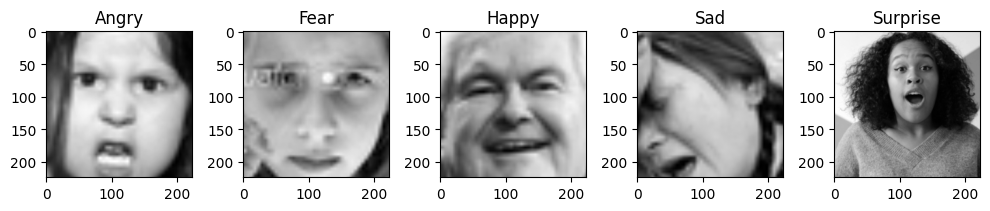

In [ ]:
plt.figure(figsize=(10,6))

plt.subplot(151)
plt.imshow(full_data[3][0].squeeze(), 'gray')
plt.title("Angry")
plt.tight_layout()

plt.subplot(152)
plt.imshow(full_data[17666][0].squeeze(), 'gray')
plt.title("Fear")
plt.tight_layout()

plt.subplot(153)
plt.imshow(full_data[24567][0].squeeze(), 'gray')
plt.title("Happy")
plt.tight_layout()

plt.subplot(154)
plt.imshow(full_data[50001][0].squeeze(), 'gray')
plt.title("Sad")
plt.tight_layout()


plt.subplot(155)
plt.imshow(full_data[-1][0].squeeze(), 'gray')
plt.title("Surprise")
plt.tight_layout()

plt.show()

* Train Test

In [ ]:
train_size = int(0.8* len(full_data))
val_size = len(full_data) - train_size

generator = torch.Generator().manual_seed(42)  # reproducibility

train_data, val_data = random_split(full_data, [train_size, val_size], generator=generator)

print(f"Training samples: {len(train_data)}")
print(f"Validation samples: {len(val_data)}")


train_loader = DataLoader(train_data, batch_size=128, shuffle=True)  #(, 1, 224, 224)
val_loader = DataLoader(val_data, batch_size=256, shuffle=False)   #(, 1, 224, 224)

Training samples: 47279
Validation samples: 11820


## a)

* Використовуючи Conv2d

In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=5):
        super(SimpleCNN, self).__init__()

        # convolutional шари
        self.conv = nn.Sequential(
            # --- Conv 1 ---
            nn.Conv2d(1, 8, kernel_size=3, padding=1),  # (B,8,H,W)
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                           # (B,8,H/2,W/2)

            # --- Conv 2 ---
            nn.Conv2d(8, 16, kernel_size=3, padding=1), # (B,16,H/2,W/2)
            nn.ReLU(),
            nn.MaxPool2d(2, 2)                           # (B,16,H/4,W/4)
        )

        # fully connected
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16 * 56 * 56, 64),                # ← нова кількість входів
            nn.ReLU(),
            nn.Linear(64, num_classes)  # кількість класів = 5
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x

model = SimpleCNN().to(device)
print(model)

SimpleCNN(
  (conv): Sequential(
    (0): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=50176, out_features=64, bias=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=5, bias=True)
  )
)


In [ ]:
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Trainable params:", num_params)

Trainable params: 3212901


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.1)  # автоматично зменшує learning rate під час тренування через кожні 20 кроків множиться на 0.1

In [ ]:
def train(model, loader, criterion, optimizer, device, scheduler=None, max_batches=None):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for i, (images, labels) in enumerate(loader):
        if max_batches is not None and i >= max_batches:
            break

        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

    avg_loss = total_loss / total
    if scheduler:
        scheduler.step()
    accuracy = 100.0 * correct / total
    return avg_loss, accuracy

In [ ]:
def evaluate(model, loader, criterion, device, max_batches=None):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for i, (images, labels) in enumerate(loader):
            if max_batches is not None and i >= max_batches:
                break

            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

    avg_loss = total_loss / total
    accuracy = 100.0 * correct / total
    return avg_loss, accuracy

Обмежимось 3ма епохами з обмеженою кількістю батчів для швидкого навчання.

In [ ]:
num_epochs = 3
best_val_acc = 0.0
patience = 3
patience_counter = 0
best_model_path = 'best_model.pth'

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}


for epoch in range(1, num_epochs + 1):
    start = time.time()
    print("start ", time.ctime(start))
    train_loss, train_acc = train(model, train_loader, criterion, optimizer, device, scheduler, max_batches=50)
    print("train done")
    val_loss, val_acc = evaluate(model, val_loader, criterion, device, max_batches=30)
    print("validation done")


    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"Epoch {epoch}/{num_epochs} ({time.time()-start:.1f}s) | "
          f"Train: {train_loss:.4f}, {train_acc:.2f}% | "
          f"Val: {val_loss:.4f}, {val_acc:.2f}%")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_val_loss = val_loss
        patience_counter = 0

        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss,
            'val_acc': val_acc,
        }, best_model_path)
        print(f" ← Best model saved!")
    else:
        patience_counter += 1
        print(f" (Patience: {patience_counter}/{patience})")

    if patience_counter >= patience:
        print(f"\nEarly stopping! No improvement for {patience} epochs.")
        break

print(f"\nFinal Validation Accuracy: {history['val_acc'][-1]:.2f}%")

start  Tue Nov 18 11:26:49 2025
train done
validation done
Epoch 1/3 (305.4s) | Train: 1.3402, 44.95% | Val: 1.3165, 45.99%
 ← Best model saved!
start  Tue Nov 18 11:31:55 2025
train done
validation done
Epoch 2/3 (290.9s) | Train: 1.2705, 48.80% | Val: 1.2999, 46.52%
 ← Best model saved!
start  Tue Nov 18 11:36:46 2025
train done
validation done
Epoch 3/3 (295.5s) | Train: 1.2299, 49.89% | Val: 1.2587, 49.19%
 ← Best model saved!

Final Validation Accuracy: 49.19%


In [ ]:
print(f"The best saved validation accuracy {best_val_acc}")

The best saved validation accuracy 49.192708333333336


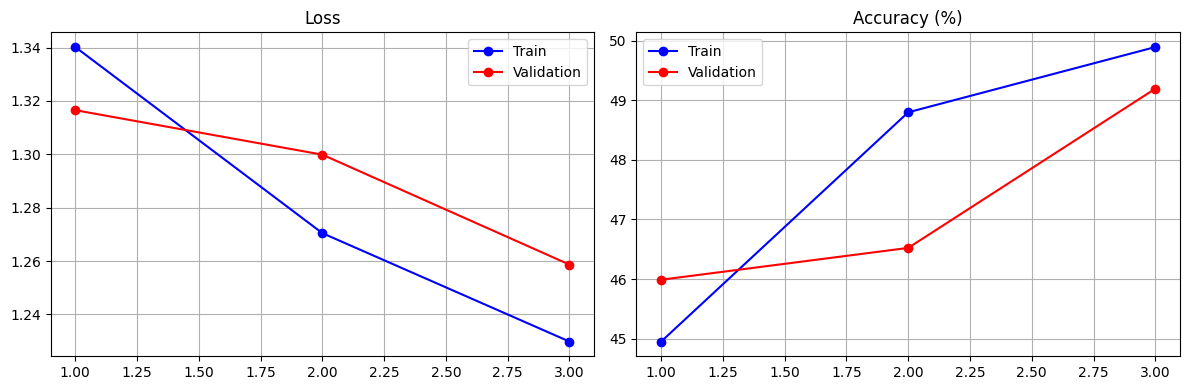

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

epochs = range(1, num_epochs + 1)
ax1.plot(epochs, history['train_loss'], 'b-o', label='Train')
ax1.plot(epochs, history['val_loss'], 'r-o', label='Validation')
ax1.set_title('Loss')
ax1.legend()
ax1.grid(True)

ax2.plot(epochs, history['train_acc'], 'b-o', label='Train')
ax2.plot(epochs, history['val_acc'], 'r-o', label='Validation')
ax2.set_title('Accuracy (%)')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

Навіть з обмеженнями моделі та її простою архітектурою, досягнуто validation accuracy 49.1927

## б)

Візьмемо ResNet18, яка вже навчена на ImageNet (1 млн зображень).
Замінюємо фінальний шар на власний (під кількість класів), та донавчаємо тільки останні шари (fine-tuning).

In [ ]:
# --- Завантаження попередньо натренованої моделі ---
resnet = models.resnet18(weights='IMAGENET1K_V1')  # попередньо натренована модель

# --- Замінюємо вихідний шар ---
num_features = resnet.fc.in_features
resnet.fc = nn.Linear(num_features, 5)  # 5 класів
resnet = resnet.to(device)

# --- Заморожуємо більшість шарів ---
for param in resnet.parameters():
    param.requires_grad = False
for param in resnet.fc.parameters():
    param.requires_grad = True  # тренуємо лише останній шар

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 148MB/s]


In [ ]:
print(resnet)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
total = sum(p.numel() for p in resnet.parameters())
trainable = sum(p.numel() for p in resnet.parameters() if p.requires_grad)

print(f"total: {total:,} | trainable: {trainable:,}")

total: 11,179,077 | trainable: 2,565


In [ ]:
num_epochs = 3
best_val_acc = 0.0
patience = 3
patience_counter = 0
best_model_path = 'best_premodel.pth'

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}


for epoch in range(1, num_epochs + 1):
    start = time.time()
    print("start ", time.ctime(start))
    train_loss, train_acc = train(model, train_loader, criterion, optimizer, device, scheduler, max_batches=50)
    print("train done")
    val_loss, val_acc = evaluate(model, val_loader, criterion, device, max_batches=30)
    print("validation done")


    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"Epoch {epoch}/{num_epochs} ({time.time()-start:.1f}s) | "
          f"Train: {train_loss:.4f}, {train_acc:.2f}% | "
          f"Val: {val_loss:.4f}, {val_acc:.2f}%")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_val_loss = val_loss
        patience_counter = 0

        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss,
            'val_acc': val_acc,
        }, best_model_path)
        print(f" ← Best model saved!")
    else:
        patience_counter += 1
        print(f" (Patience: {patience_counter}/{patience})")

    if patience_counter >= patience:
        print(f"\nEarly stopping! No improvement for {patience} epochs.")
        break

print(f"\nFinal Validation Accuracy: {history['val_acc'][-1]:.2f}%")

start  Tue Nov 18 11:54:17 2025
train done
validation done
Epoch 1/3 (285.4s) | Train: 1.2021, 51.53% | Val: 1.2507, 49.70%
 ← Best model saved!
start  Tue Nov 18 11:59:03 2025
train done
validation done
Epoch 2/3 (284.1s) | Train: 1.1641, 54.20% | Val: 1.2218, 50.94%
 ← Best model saved!
start  Tue Nov 18 12:03:47 2025
train done
validation done
Epoch 3/3 (295.0s) | Train: 1.1045, 56.75% | Val: 1.1960, 51.17%
 ← Best model saved!

Final Validation Accuracy: 51.17%


In [ ]:
print(f"The best saved validation accuracy {best_val_acc}")

The best saved validation accuracy 51.171875


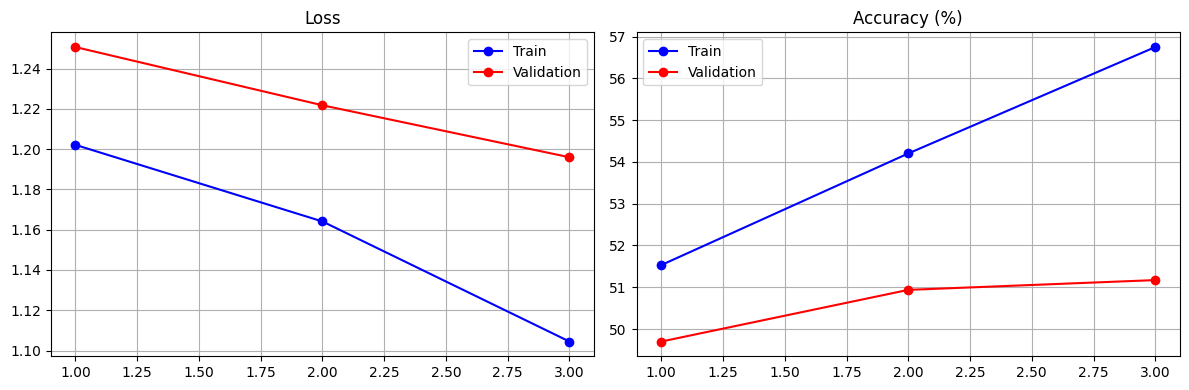

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

epochs = range(1, num_epochs + 1)
ax1.plot(epochs, history['train_loss'], 'b-o', label='Train')
ax1.plot(epochs, history['val_loss'], 'r-o', label='Validation')
ax1.set_title('Loss')
ax1.legend()
ax1.grid(True)

ax2.plot(epochs, history['train_acc'], 'b-o', label='Train')
ax2.plot(epochs, history['val_acc'], 'r-o', label='Validation')
ax2.set_title('Accuracy (%)')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

## Висновки

Попередньо натренована модель за 3 епохи навчилась дещо краще чим з нуля створена згорткова мережа, хоча, як видно, модель з кожною епохою демонструє збільшення різниці Loss та Accuracy, тим не менше обидві моделі навчаються та з кожною епохою покращують результат.
* Для Conv model validation accuracy 49.192708, Trainable params: 3212901
* Для Pretrained model validation accuracy 51.171875, Total params: 11,179,077 | Trainable params: 2,565


Train accuracy зростає швидше у Pretrained model (51% → 56.7%) порівняно з Conv model (44.9% → 49.9%). Val accuracy теж трохи краща у Pretrained model (51.2% vs 49.2%), тобто модель швидше навчається і краще узагальнює. Втрати (loss) у Pretrained model зменшуються швидше, особливо на тренувальних даних. Час на епоху майже не змінився, тож швидкість збіжності покращилася без додаткових витрат часу.

# Task 3

3. Вирішіть задачу класифікації текстів (використайте той же
датасет, з яким ви працювали в лабораторній № 2) двома способами:
а) Побудуйте модель з вбудованим Embedding шаром (ініціалізованим випадковими вагами). Використайте RNN / LSTM / GRU для класифікації. Навчіть модель на вашому датасеті.
б) Завантажте готові embeddings (наприклад, GloVe). Ініціалізуйте Embedding шар цими вагами.
Проведіть навчання.
Порівняйте якість класифікації у (а) та (б). Чи покращилися метрики
при використанні pretrained embeddings? Наскільки швидше/стабільніше відбулося
навчання?

## Data

Посилання на опис датасету https://www.kaggle.com/datasets/nikhileswarkomati/suicide-watch

In [7]:
# Download latest version
path = kagglehub.dataset_download("nikhileswarkomati/suicide-watch")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'suicide-watch' dataset.
Path to dataset files: /kaggle/input/suicide-watch


In [8]:
files = os.listdir(path)
print("Files in dataset folder:", files)

csv_path = os.path.join(path, "Suicide_Detection.csv")

# Завантажуємо CSV
df = pd.read_csv(csv_path)
df = df.drop(columns=["Unnamed: 0"])
df.head()

Files in dataset folder: ['Suicide_Detection.csv']


,text,class
0,Ex Wife Threatening SuicideRecently I left my ...,suicide
1,Am I weird I don't get affected by compliments...,non-suicide
2,Finally 2020 is almost over... So I can never ...,non-suicide
3,i need helpjust help me im crying so hard,suicide
4,"I’m so lostHello, my name is Adam (16) and I’v...",suicide


In [9]:
df.columns, df.shape

(Index(['text', 'class'], dtype='object'), (232074, 2))

* Clean dataset

In [10]:
def clean_text(text):
    # Якщо текст не є рядком — перетворюємо
    text = str(text)

    # Розділення слів, де є велика літера всередині, наприклад "SuicideRecently" → "Suicide Recently"
    text = re.sub(r'([a-z])([A-Z])', r'\1 \2', text)

    # Приводимо до нижнього регістру
    text = text.lower()

    # Видаляємо згадки, URL, хештеги
    text = re.sub(r"@\S+", " ", text)
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"#\S+", " ", text)

    # Видаляємо числа
    text = re.sub(r"\d+", " ", text)

    # Видаляємо пунктуацію
    text = re.sub(rf"[{re.escape(string.punctuation)}]", " ", text)

    # Видаляємо перенос рядків та зайві пробіли
    text = re.sub(r"[\r\n]+", " ", text)
    text = re.sub(r"\s{2,}", " ", text)

    return text.strip()

In [11]:
df['clean_text'] = df['text'].apply(clean_text)

In [12]:
df.head()

,text,class,clean_text
0,Ex Wife Threatening SuicideRecently I left my ...,suicide,ex wife threatening suicide recently i left my...
1,Am I weird I don't get affected by compliments...,non-suicide,am i weird i don t get affected by compliments...
2,Finally 2020 is almost over... So I can never ...,non-suicide,finally is almost over so i can never hear has...
3,i need helpjust help me im crying so hard,suicide,i need helpjust help me im crying so hard
4,"I’m so lostHello, my name is Adam (16) and I’v...",suicide,i’m so lost hello my name is adam and i’ve bee...


In [13]:
# Токенізуємо по словах
tokens = [word_tokenize(t) for t in df['clean_text']]

In [14]:
counter = Counter(w for sent in tokens for w in sent)

# кількість унікальних слів
vocab_size = len(counter)

print(f"Кількість унікальних слів у train-наборі: {vocab_size:,}")

Кількість унікальних слів у train-наборі: 144,567


Спробуємо зменшити словник. Візьмемо закон Зіпфа

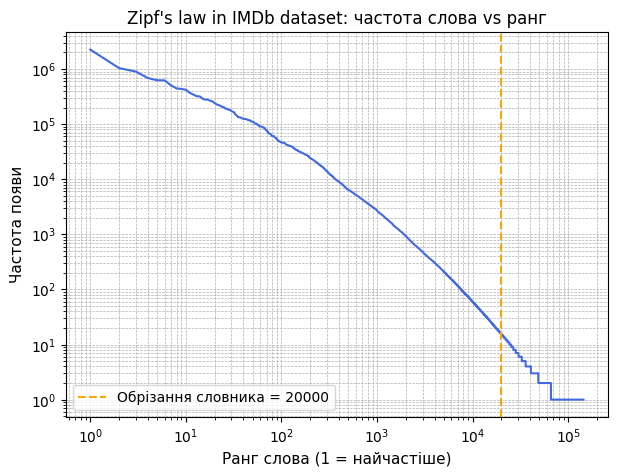

In [15]:
word_freqs = np.array(sorted(counter.values(), reverse=True))
ranks = np.arange(1, len(word_freqs) + 1)

plt.figure(figsize=(7, 5))
plt.loglog(ranks, word_freqs, color='royalblue')
plt.title("Zipf's law in IMDb dataset: частота слова vs ранг", fontsize=12)
plt.xlabel("Ранг слова (1 = найчастіше)", fontsize=11)
plt.ylabel("Частота появи", fontsize=11)
plt.grid(True, which="both", ls="--", lw=0.5)

 # обмежимо словник
MAX_VOCAB = 20_000
plt.axvline(MAX_VOCAB, color='orange', linestyle='--', label=f'Обрізання словника = {MAX_VOCAB}')
plt.legend()

plt.show()

Оскільки прибираємо слова, то потрібно ввести технічний токен UNK (unknown) та токен PAD (padding) (як в зображеннях - доповнення нулями (як рамочка)) оскільки на LSTM мають подаватися токени однієї довжини.

In [16]:
# створюємо списки перетворень, створюємо словник
specials = ["[PAD]", "[UNK]"]

# 20000-2 слів у вигляді (слово, кількість)
most_common = counter.most_common(MAX_VOCAB - len(specials))  # 20000-2

# список слів у порядку спадання їх кількості у тексті
# index to sequence
itos = specials + [w for w, _ in most_common]       # index → string

# створення словника {work: index} де index тим менше, чим важливіше слово
stoi = {w: i for i, w in enumerate(itos)}           # string → index

PAD_IDX = stoi["[PAD]"]  # 0
UNK_IDX = stoi["[UNK]"]  # 1

print("Розмір словника:", len(stoi))
print("Приклад індексу:", stoi.get("suicide", UNK_IDX))

Розмір словника: 20000
Приклад індексу: 133


Кодуємо тексти у послідовності індексів, для кожного токена беремо його індекс зі словника stoi, якщо слова немає — повертаємо індекс UNK_IDX.

In [17]:
def encode(tokens):
    return [stoi.get(t, UNK_IDX) for t in tokens]

encoded_texts = [encode(tok_list) for tok_list in tokens]
print(encoded_texts[0][:20])  # перші 20 слів

[500, 696, 2356, 133, 384, 2, 238, 7, 696, 17, 100, 52, 40, 89, 1328, 32, 11, 999, 4, 1368]


Padding (вирівнюємо довжину). Нейронна мережа очікує тензори однакової довжини, тому короткі тексти “доповнюємо” , а надто довгі — обрізаємо

In [18]:
MAX_LEN = 100   # довжина послідовності
def pad_sequence(seq):
    seq = seq[:MAX_LEN] + [PAD_IDX] * max(0, MAX_LEN - len(seq))
    return torch.tensor(seq, dtype=torch.long)

* X

In [19]:
X = torch.stack([pad_sequence(seq) for seq in encoded_texts])
print(X.shape)   # [N, MAX_LEN]

torch.Size([232074, 100])


* y

In [20]:
# encode classes
le = LabelEncoder()
y_np = le.fit_transform(df["class"])   # numpy масив чисел

# convert to tensor
y = torch.tensor(y_np, dtype=torch.float32)  # не застосовуємо CrossEntropyLoss, тому .long не потрібно

print(y[:10])
print(y.shape)

tensor([1., 0., 0., 1., 1., 1., 1., 1., 0., 1.])
torch.Size([232074])


Train Test split

In [21]:
#TensorDataset і DataLoader
dataset = TensorDataset(X, y)

# розділяємо на train/val
VAL_FRAC = 0.2
val_sz = int(len(dataset) * VAL_FRAC)
train_sz = len(dataset) - val_sz
train_ds, val_ds = random_split(dataset, [train_sz, val_sz],
                                generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=128)

## a)

Коментар з практичного заняття: n.Embedding(vocab_size, emb_dim) — створює матрицю розміром [vocab_size × emb_dim], де кожне слово отримує свій вектор. pad_idx гарантує, що завжди отримає нульовий вектор і не впливатиме на навчання.

In [26]:
class BiLSTM_IMDB(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim, pad_idx, num_layers=2):
        super().__init__()

        # Embedding шар
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_idx)

        # Bidirectional LSTM для класифікації
        self.lstm = nn.LSTM(
            input_size=emb_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True
        )
        self.fc = nn.Linear(hidden_dim * 2, 1)   # *2 оскільки BiLSTM, 1 оскільки бінарна класифікація для нашої задачі

    def forward(self, x):
        # x: [batch, seq_len] з падінгом pad_idx
        x = self.embedding(x)     # [B, T, emb_dim]

        out, (h, c) = self.lstm(x)
        # h: [num_layers*2, B, hidden_dim]
        # беремо останній шар: forward = -2, backward = -1
        h_fwd = h[-2, :, :]
        h_bwd = h[-1, :, :]
        # concatination
        h_cat = torch.cat([h_fwd, h_bwd], dim=1) # [B, 2*hidden_dim]

        logits = self.fc(h_cat)  # [B, 1]
        return logits.squeeze(1)  # [B]


In [27]:
vocab_size = len(stoi)
emb_dim = 100  # for Glove
hidden_dim = 64
pad_idx = stoi["[PAD]"]

model = BiLSTM_IMDB(vocab_size, emb_dim, hidden_dim, pad_idx).to(device)
print(model)

BiLSTM_IMDB(
  (embedding): Embedding(20000, 100, padding_idx=0)
  (lstm): LSTM(100, 64, num_layers=2, batch_first=True, bidirectional=True)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)


Коментар з практичного заняття: Функція втрат для бінарної класифікації nn.BCEWithLogitsLoss() — всередині вже має сигмоїду, тому в моделі НЕ ставимо nn.Sigmoid() перед виходом. Якщо замість неї використовувати nn.BCELoss(), тоді потрібно ДОДАТИ сигмоїду (наприклад, torch.sigmoid або nn.Sigmoid).

In [28]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.1)  # автоматично зменшує learning rate під час тренування через кожні 20 кроків множиться на 0.1

З другого завдання функції train та evaluate з деякими змінами у коді

In [29]:
def train(model, loader, criterion, optimizer, device, scheduler=None, max_batches=None):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for i, (inputs, labels) in enumerate(loader):
        if max_batches is not None and i >= max_batches:
            break

        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()

        # forward
        outputs = model(inputs)  # [B]
        loss = criterion(outputs, labels.float())  # BCEWithLogitsLoss очікує float

        # backward
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        # accumulate loss
        total_loss += loss.item() * inputs.size(0)

        # accuracy
        preds = (outputs >= 0.0).long()  # для бінарної класифікації
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    if scheduler:
        scheduler.step()

    avg_loss = total_loss / total
    accuracy = 100.0 * correct / total
    return avg_loss, accuracy


In [30]:
def evaluate(model, loader, criterion, device, max_batches=None):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(loader):
            if max_batches is not None and i >= max_batches:
                break

            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)  # [B]

            loss = criterion(outputs, labels.float())  # BCEWithLogitsLoss очікує float
            total_loss += loss.item() * labels.size(0)

            preds = (outputs >= 0.0).long()  # для бінарної класифікації
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avg_loss = total_loss / total
    accuracy = 100.0 * correct / total
    return avg_loss, accuracy


Перевіримо яка загальна кількість батчів

In [31]:
num_train_batches = len(train_loader)
num_val_batches = len(val_loader)

print(f"Train batches: {num_train_batches}")
print(f"Validation batches: {num_val_batches}")

Train batches: 1451
Validation batches: 363


In [ ]:
num_epochs = 7
best_val_acc = 0.0
best_val_loss = float('inf')
patience = 3
patience_counter = 0
best_model_path = 'BiLSTM_best_model.pth'

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}


for epoch in range(1, num_epochs + 1):
    start = time.time()
    print("start ", time.ctime(start))
    train_loss, train_acc = train(model, train_loader, criterion, optimizer, device, scheduler, max_batches=300)
    print("train done")
    val_loss, val_acc = evaluate(model, val_loader, criterion, device, max_batches=100)
    print("validation done")


    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"Epoch {epoch}/{num_epochs} ({time.time()-start:.1f}s) | "
          f"Train: {train_loss:.4f}, {train_acc:.2f}% | "
          f"Val: {val_loss:.4f}, {val_acc:.2f}%")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_val_loss = val_loss
        patience_counter = 0

        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss,
            'val_acc': val_acc,
        }, best_model_path)
        print(f" ← Best model saved!")
    else:
        patience_counter += 1
        print(f" (Patience: {patience_counter}/{patience})")

    if patience_counter >= patience:
        print(f"\nEarly stopping! No improvement for {patience} epochs.")
        break

print(f"\nFinal Validation Accuracy: {history['val_acc'][-1]:.2f}%")

start  Wed Nov 19 10:02:48 2025
train done
validation done
Epoch 1/7 (87.9s) | Train: 0.2132, 91.95% | Val: 0.2059, 92.14%
 ← Best model saved!
start  Wed Nov 19 10:04:16 2025
train done
validation done
Epoch 2/7 (86.6s) | Train: 0.2033, 92.34% | Val: 0.1998, 92.54%
 ← Best model saved!
start  Wed Nov 19 10:05:43 2025
train done
validation done
Epoch 3/7 (85.5s) | Train: 0.1842, 93.21% | Val: 0.4515, 79.29%
 (Patience: 1/3)
start  Wed Nov 19 10:07:08 2025
train done
validation done
Epoch 4/7 (87.6s) | Train: 0.1784, 93.37% | Val: 0.1893, 92.75%
 ← Best model saved!
start  Wed Nov 19 10:08:36 2025
train done
validation done
Epoch 5/7 (86.7s) | Train: 0.1706, 93.71% | Val: 0.1945, 93.00%
 ← Best model saved!
start  Wed Nov 19 10:10:03 2025
train done
validation done
Epoch 6/7 (87.7s) | Train: 0.1631, 94.09% | Val: 0.1810, 93.34%
 ← Best model saved!
start  Wed Nov 19 10:11:30 2025
train done
validation done
Epoch 7/7 (86.7s) | Train: 0.1558, 94.32% | Val: 0.1775, 93.27%
 (Patience: 1/3)


In [ ]:
print(f"The best saved validation accuracy {best_val_acc}")

The best saved validation accuracy 93.34375


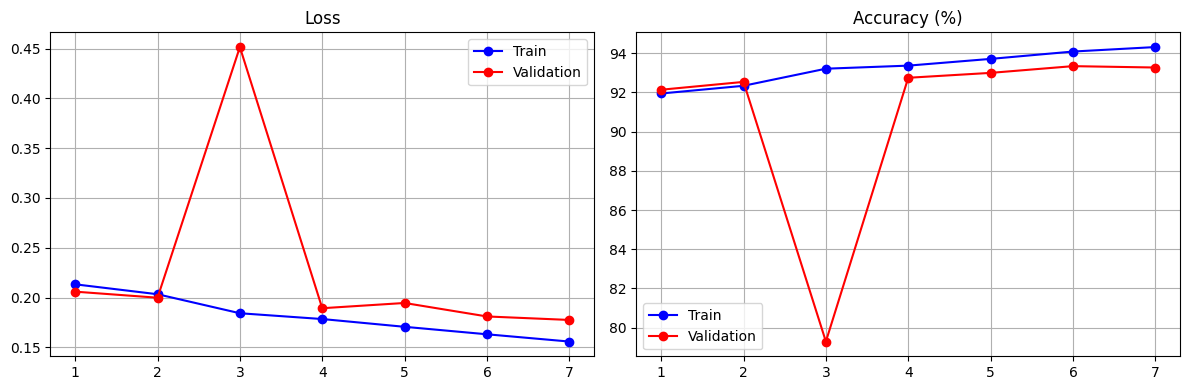

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

epochs = range(1, num_epochs + 1)
ax1.plot(epochs, history['train_loss'], 'b-o', label='Train')
ax1.plot(epochs, history['val_loss'], 'r-o', label='Validation')
ax1.set_title('Loss')
ax1.legend()
ax1.grid(True)

ax2.plot(epochs, history['train_acc'], 'b-o', label='Train')
ax2.plot(epochs, history['val_acc'], 'r-o', label='Validation')
ax2.set_title('Accuracy (%)')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

Це явище зазвичай пов’язане не з "поганим навчанням", а з тим, що валидація на деяких батчах потрапила на аномальні дані. Це може бути через:
* Нестабільність при використанні max_batches
* Випадковість порядку даних (shuffle)
* Малі розміри батчів

## б)

З використанням Glove

In [3]:
# завантаження з репозиторію
!wget -q http://nlp.stanford.edu/data/glove.6B.zip
!unzip -q glove.6B.zip

У папці наявні файли: glove.6B.50d.txt, glove.6B.100d.txt, glove.6B.200d.txt, glove.6B.300d.txt. Оберемо glove.6B.100d.txt

GloVe — всі слова в lowercase, не прибираються стоп-слова; не виконується лематизація чи стемінг, отже і наші дані таким чином оброблятися не будуть.

In [4]:
#читаємо файл у словник word -> vector
def load_glove_txt(path):
    vectors = {}
    with open(path, "r", encoding="utf8") as f:
        for line in f:
            parts = line.rstrip().split(" ")
            word = parts[0]
            vec = np.asarray(parts[1:], dtype=np.float32)
            vectors[word] = vec
    dim = len(next(iter(vectors.values())))
    return vectors, dim

glove_path = "glove.6B.100d.txt"
glove, emb_dim = load_glove_txt(glove_path)
print("GloVe dim:", emb_dim, "| entries:", len(glove))

GloVe dim: 100 | entries: 400000


In [5]:
#приклад embeddings
for w in ["hell", "suicide", "death", "bad"]:
    print(w, glove[w][:10])  # перші 10 компонент

hell [ 0.16576   0.10361   0.84759  -0.8608   -0.072553  0.37317  -0.22885
  0.19404   0.080844 -0.42787 ]
suicide [-0.38132 -0.29828 -0.75109 -0.11481  0.11429  0.81256  0.21916 -0.56321
  0.11511  1.2207 ]
death [ 0.46779 -0.23088 -0.11697 -0.22404  0.11322  1.0327  -0.21111 -0.31715
 -0.22839 -0.12901]
bad [ 0.39456  -0.24717   1.0319   -0.61444  -1.2376    0.051794 -0.55112
 -0.31014  -0.025735 -0.24709 ]


Оскільки значення вектору для кожного слова (тобто, ваги) вже відомі, вони будуть заміною значень для аналогічних слів у нашому словнику.

In [32]:
# збираємо embedding-матрицю під наш словник stoi
vocab_size = len(stoi)
PAD_IDX = stoi["[PAD]"]
UNK_IDX = stoi["[UNK]"]

emb_matrix = np.random.normal(scale=0.1, size=(vocab_size, emb_dim)).astype(np.float32)
emb_matrix[PAD_IDX] = 0.0  # пад завжди нульовий

hit = 0
for w, idx in stoi.items():
    v = glove.get(w)                      # w має бути в lower()
    if v is not None:
        emb_matrix[idx] = v
        hit += 1
print(f"Coverage: {hit}/{vocab_size} = {hit/vocab_size:.1%}")

Coverage: 18750/20000 = 93.8%


93.8% слів було знайдено з уже відомими вагами GloVe.

In [33]:
# Готові embeddings (GloVe). Ініціалізуйте Embedding шар цими вагами
pretrained_emb = nn.Embedding.from_pretrained(
    torch.tensor(emb_matrix),
    freeze=True,                #заморозити
    padding_idx=PAD_IDX
).to(device)

# emb_dim = 100  # for Glove
# hidden_dim = 64
# pad_idx = stoi["[PAD]"]

model_tl = BiLSTM_IMDB(vocab_size, emb_dim, hidden_dim, pad_idx).to(device)

# Підміняємо шар у моделі
model_tl.embedding = pretrained_emb


In [34]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model_tl.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.1)  # автоматично зменшує learning rate під час тренування через кожні 20 кроків множиться на 0.1

In [36]:
num_epochs = 7
best_val_acc = 0.0
best_val_loss = float('inf')
patience = 3
patience_counter = 0
best_model_path = 'pre_trained_BiLSTM_best_model.pth'

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}


for epoch in range(1, num_epochs + 1):
    start = time.time()
    print("start ", time.ctime(start))
    train_loss, train_acc = train(model_tl, train_loader, criterion, optimizer, device, scheduler, max_batches=300)
    print("train done")
    val_loss, val_acc = evaluate(model_tl, val_loader, criterion, device, max_batches=100)
    print("validation done")


    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"Epoch {epoch}/{num_epochs} ({time.time()-start:.1f}s) | "
          f"Train: {train_loss:.4f}, {train_acc:.2f}% | "
          f"Val: {val_loss:.4f}, {val_acc:.2f}%")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_val_loss = val_loss
        patience_counter = 0

        torch.save({
            'epoch': epoch,
            'model_state_dict': model_tl.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss,
            'val_acc': val_acc,
        }, best_model_path)
        print(f" ← Best model saved!")
    else:
        patience_counter += 1
        print(f" (Patience: {patience_counter}/{patience})")

    if patience_counter >= patience:
        print(f"\nEarly stopping! No improvement for {patience} epochs.")
        break

print(f"\nFinal Validation Accuracy: {history['val_acc'][-1]:.2f}%")

start  Wed Nov 19 14:47:10 2025
train done
validation done
Epoch 1/7 (180.4s) | Train: 0.3189, 87.14% | Val: 0.2714, 89.16%
 ← Best model saved!
start  Wed Nov 19 14:50:10 2025
train done
validation done
Epoch 2/7 (174.6s) | Train: 0.2782, 88.79% | Val: 0.2631, 89.39%
 ← Best model saved!
start  Wed Nov 19 14:53:05 2025
train done
validation done
Epoch 3/7 (171.9s) | Train: 0.2512, 90.16% | Val: 0.2353, 90.79%
 ← Best model saved!
start  Wed Nov 19 14:55:57 2025
train done
validation done
Epoch 4/7 (198.7s) | Train: 0.2289, 91.16% | Val: 0.2220, 91.25%
 ← Best model saved!
start  Wed Nov 19 14:59:15 2025
train done
validation done
Epoch 5/7 (208.1s) | Train: 0.2245, 91.29% | Val: 0.2112, 91.87%
 ← Best model saved!
start  Wed Nov 19 15:02:44 2025
train done
validation done
Epoch 6/7 (211.8s) | Train: 0.2121, 91.81% | Val: 0.2101, 92.27%
 ← Best model saved!
start  Wed Nov 19 15:06:15 2025
train done
validation done
Epoch 7/7 (196.7s) | Train: 0.2015, 92.30% | Val: 0.2023, 92.20%
 (Pati

In [37]:
print(f"The best saved validation accuracy {best_val_acc}")

The best saved validation accuracy 92.2734375


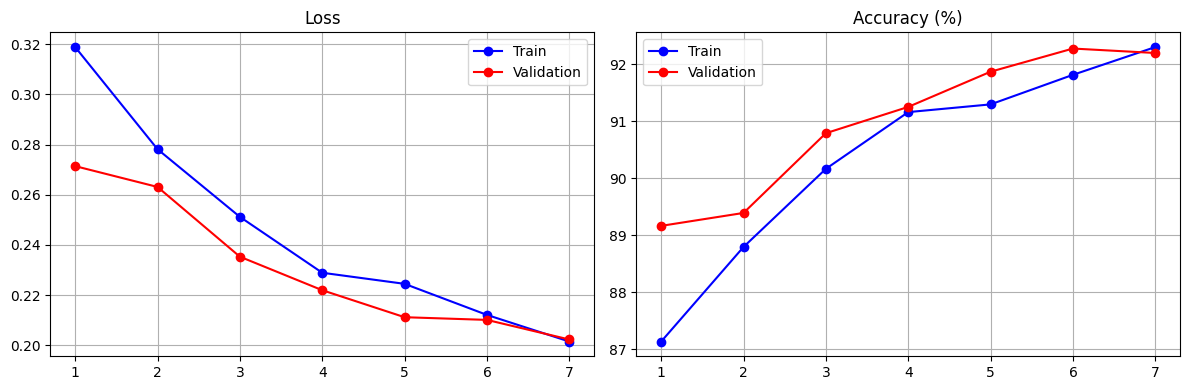

In [38]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

epochs = range(1, num_epochs + 1)
ax1.plot(epochs, history['train_loss'], 'b-o', label='Train')
ax1.plot(epochs, history['val_loss'], 'r-o', label='Validation')
ax1.set_title('Loss')
ax1.legend()
ax1.grid(True)

ax2.plot(epochs, history['train_acc'], 'b-o', label='Train')
ax2.plot(epochs, history['val_acc'], 'r-o', label='Validation')
ax2.set_title('Accuracy (%)')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

## Висновки

Обидві моделі навчалися на обмеженій кількості епох = 7 та з неповним набором батчів (для тренування 300 з 1451, для валідації 100 з 363).
* Модель з випадку а) з вбудованим Embedding шаром (ініціалізованим випадковими вагами) показала best validation accuracy 93.34375
* Модель з випадку б) з уже відомими вагами Embedding шару показала best validation accuracy 92.27344
* Для порівняння: З Лабораторної роботи №2 LogisticRegression для усіх даних після обробки, але перед алгоритмічним обрізанням закінчень (Stemming) - тобто дані як для рекурентних мереж - показала Accuracy: 0.919918

1) Якість класифікації

а) Модель тренується швидко та досягає високої точності, є аномальний спад до 79% при валідації (причини описано вище в розділі а))

б) Прогрес рівний, але фінальна точність нижча, ніж у Random Embeddings.

Тому, що BiLSTM має достатньо потужності, щоб самостійно вивчити embeddings краще, ніж GloVe.

2) Швидкість навчання

а) Random: ~87 сек/епоха

б) GloVe: ~190–210 сек/епоха (оскільки Embedding tensor від GloVe значно більший)

3) Стабільність навчання

а) Має різкий провал на 3-й епосі (Val 79%), але повністю відновлюється → стабілізується на 93%.

б) Дуже стабільне і рівне тренування, валідаційна точність монотонно зростає.
